# Explanatory Data Analysis for a US Multi-City Retailer

Consultant EDA of `retail_data.csv` (Kaggle *Retail Data*; Khan, n.d.).

**M504C AI and Applications - Individual Project**

**Individual Project:** Building and Evaluating an Data Analysis Pipeline for Business.

**Name:** Madhukeshwargouda Gurunathgouda Patil

**GH Number:** GH1049474

**Program:** MSc Data Science AI and Digital Business

**Course:** M504C AI and Applications

**Module Tutor:** Prof. Dr. Muhammad Tanvir Afzal

**Title:** Individual Project

**Primary Topic:** Building and Evaluating an Data Analysis Pipeline for Business.

**Github link:** https://github.com/danielfisshah-ui/M505-Intro-to-ML-and-AI

**DataSet link** https://www.kaggle.com/datasets/abdurraziq01/retail-data

Date of Submission: 18.09.2026


## 1. Business context

Northline Retail is a fictional multi-city US retailer. We were asked to perform an EDA on this 200,000+ row data extract from 10 cities over 3 years (July 14, 2020 to July 14, 2023) for variables such as profit, discount, marketing, competition with other retailers, and operations. Northline would like to use this data to analyze observed customer, pricing, and operational behavior to make business decisions. We will also examine the limitations of the data extract provided to us.

This file is a public Kaggle extract and NOT the audit accounts for Northline Retail.


## 2. Dataset overview

Each row is one purchase from a unique customer (as identified by CustomerID – no repeat customers). This data was retrieved from the retail data on kaggle (https://www.kaggle.com/datasets/abdurraziq01/retail-data) (17 September 2026). The column names were checked against dfasure (n.d.) for this observation but that data was not used for anything.

## 3. Data exploration


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 12)
plt.rcParams.update({
    'figure.dpi': 72,
    'savefig.dpi': 72,
    'axes.grid': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

df_raw = pd.read_csv('retail_data.csv')
print('shape:', df_raw.shape)
num = df_raw.select_dtypes(include='number')
profile = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'missing': df_raw.isna().sum(),
    'unique': df_raw.nunique(),
    'min': num.min(),
    'max': num.max(),
})
profile = profile.reindex(df_raw.columns)
profile


shape: (200000, 19)


,dtype,missing,unique,min,max
CustomerID,int64,0,200000,1.00,"200,000.00"
Age,int64,0,53,18.00,70.00
Gender,object,0,2,NaN,NaN
AnnualIncome,int64,0,102310,"20,001.00","150,000.00"
SpendingScore,int64,0,100,1.00,100.00
ProductCategory,object,0,6,NaN,NaN
ProductPrice,float64,0,85933,10.00,"1,000.00"
PurchaseDate,object,0,1096,NaN,NaN
StoreID,int64,0,100,1.00,100.00
StoreLocation,object,0,10,NaN,NaN


In [2]:
print(df_raw['ProductCategory'].value_counts())
print(df_raw['StoreLocation'].value_counts())
print(df_raw['PaymentMethod'].value_counts())


ProductCategory
Books              33479
Groceries          33382
Electronics        33380
Clothing           33348
Home & Kitchen     33239
Health & Beauty    33172
Name: count, dtype: int64
StoreLocation
Phoenix         20109
Los Angeles     20100
San Diego       20074
San Jose        20043
Houston         20017
Chicago         19977
San Antonio     19962
Dallas          19950
New York        19915
Philadelphia    19853
Name: count, dtype: int64
PaymentMethod
Mobile Payment     40262
Debit Card         40144
Credit Card        40062
Online Transfer    39910
Cash               39622
Name: count, dtype: int64


**Observed.** The dataset consists of 200,000 * 19 numbers with no missing values. There are bounded ranges for a few values (e.g. age = [18; 70], price = [$10; $1000], discount = [0; 30]). The vast majority of categories are almost uniform, e.g. customer/source/city/payment method/gender/discount flag.

**Inference (not a provenance label)**: We can see that there is a strong mechanical relationship between the Profit, ProductPrice and the DiscountPercent. Also, the categorical distributions are highly uniform. It appears that some of the variables have been constructed for this dataset, rather than having been gathered as independent data from within a business. Thus this data is not suited for causal or financial analysis.

## 4. Data quality findings


In [3]:
print('duplicate rows:', int(df_raw.duplicated().sum()),
      '| unique customers:', df_raw['CustomerID'].nunique(),
      '| customer ID unique:', df_raw['CustomerID'].is_unique)
print('locations per StoreID min/max:',
      int(df_raw.groupby('StoreID')['StoreLocation'].nunique().min()),
      int(df_raw.groupby('StoreID')['StoreLocation'].nunique().max()),
      '| ID–city pairs:', df_raw.groupby(['StoreID','StoreLocation']).ngroups)
print('flag True and 0 pct discount:', int((df_raw['DiscountApplied'] & (df_raw['DiscountPercent'] == 0)).sum()))
print('inventory 0:', int((df_raw['InventoryLevel'] == 0).sum()))
print('max |Profit − Price×Discount%|:',
      float((df_raw['Profit'] - df_raw['ProductPrice'] * df_raw['DiscountPercent'] / 100).abs().max()))
print('max |Profit − (Price − Cost)|:',
      float((df_raw['Profit'] - (df_raw['ProductPrice'] - df_raw['ProductCost'])).abs().max()))


duplicate rows: 0 | unique customers: 200000 | customer ID unique: True
locations per StoreID min/max: 10 10 | ID–city pairs: 1000
flag True and 0 pct discount: 3214
inventory 0: 1986
max |Profit − Price×Discount%|: 0.005000000000080718
max |Profit − (Price − Cost)|: 2.842170943040401e-14


**Observed facts.** There are no duplicate rows in the ‘Data2’ tab; each customer has a unique CustomerID. This data can be Date parsed in the next section of notes.

**Issues kept (not dropped).**
1. `Profit = Price − Cost = Price × Discount%` (rounding only). Undiscounted rows have profit 0.
2. The `StoreID` values appear in all 10 cities and are not a key for a store.
3. 3,214 rows have `DiscountApplied=True` with 0% (profit 0).
4. 1,986 sales at inventory 0.
5. High profit values are very high because of high price * high discount%, not errors.

Traffic, inventory and marketing vary for individual products within a StoreID (row-level).

## 5. Data preprocessing

The source CSV file is not overwritten. The date column PurchaseDate is parsed. In addition to the already present recorded profit in file field “RecordedMargin” the year and month, the price gap and its percent and the inconsistent discounts are calculated. Location is set to city. All rows are kept, imputation and de-duplication are not done.

In [4]:
df = df_raw.copy()
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'], errors='coerce')
assert df['PurchaseDate'].isna().sum() == 0
print(df['PurchaseDate'].min().date(), '→', df['PurchaseDate'].max().date(),
      '| unique dates:', df['PurchaseDate'].nunique())
df['YearMonth'] = df['PurchaseDate'].dt.to_period('M')
df['RecordedMargin'] = df['Profit'] / df['ProductPrice']
df['PriceGap'] = df['ProductPrice'] - df['CompetitorPrice']
df['PriceGapPct'] = df['PriceGap'] / df['ProductPrice'] * 100
df['DiscountInconsistent'] = df['DiscountApplied'] & (df['DiscountPercent'] == 0)
print('inconsistent flags:', int(df['DiscountInconsistent'].sum()))


2020-07-14 → 2023-07-14 | unique dates: 1096
inconsistent flags: 3214


## 6. Business questions

Eight observational questions about our store and source data using ‘Recorded profit’ file field value. All calculations here are done using the full 200,000 rows of source data. Scatterplots are done on a sample of df (using df.sample(2000, random_state=42) ) to avoid overplotting.

### Business Question 1 — Category margin, price positioning, and assortment usefulness

**Business importance.** Assortment needs independent category economics. If recorded margin only restates discount, this extract cannot guide space or ranging.


In [5]:
q1 = (df.groupby('ProductCategory')
        .agg(n=('Profit', 'size'),
             median_price=('ProductPrice', 'median'),
             mean_gap_pct=('PriceGapPct', 'mean'),
             mean_disc_pct=('DiscountPercent', 'mean'),
             mean_margin=('RecordedMargin', 'mean'),
             mean_profit=('Profit', 'mean'))
        .sort_values('mean_margin', ascending=False))
q1['margin_vs_all_pct'] = 100 * (q1['mean_margin'] / df['RecordedMargin'].mean() - 1)
q1['price_vs_all_pct'] = 100 * (q1['median_price'] / df['ProductPrice'].median() - 1)
q1


,n,median_price,mean_gap_pct,mean_disc_pct,mean_margin,mean_profit,margin_vs_all_pct,price_vs_all_pct
ProductCategory,,,,,,,,
Books,33479,505.95,0.00,7.57,0.08,38.38,1.09,0.25
Clothing,33348,507.11,0.01,7.54,0.08,38.19,0.73,0.48
Health & Beauty,33172,502.83,0.02,7.49,0.07,37.44,0.06,-0.37
Groceries,33382,506.48,-0.01,7.47,0.07,37.53,-0.14,0.36
Home & Kitchen,33239,504.60,-0.08,7.47,0.07,37.94,-0.22,-0.01
Electronics,33380,501.29,-0.10,7.37,0.07,36.85,-1.52,-0.67


**Interpretation.** Median prices for each category are nearly equal to the mean `PriceGapPct` for that category. The recorded margin is approximately equal to the recorded margin for the store as a whole (near the overall mean) plus or minus 2% for each category. In essence, this data cannot be used to make appropriate assortment decisions based on recorded profit as that number is determined by the same formulas used for determining discount. **Answer:** The data cannot support assortment decisions from recorded profit. **Limitation:** No independent COGS to make recorded margin (as recorded margin equals discount) meaningful.

### Business Question 2 — Discounting and recorded profitability

**Business importance.** Markdown tests are only valid if recorded profit is independent of the discount.


In [6]:
print('flag True and 0%:', int(df['DiscountInconsistent'].sum()))
df['DiscountBand'] = pd.cut(df['DiscountPercent'], bins=[-0.1, 0, 10, 20, 30],
                            labels=['0%', '1–10%', '11–20%', '21–30%'])
q2 = (df.groupby('DiscountBand', observed=True)
        .agg(n=('Profit', 'size'), avg_price=('ProductPrice', 'mean'),
             avg_profit=('Profit', 'mean'), avg_margin=('RecordedMargin', 'mean')))
q2['avg_margin'] *= 100
q2


flag True and 0%: 3214


,n,avg_price,avg_profit,avg_margin
DiscountBand,,,,
0%,103294,505.46,0.00,0.00
1–10%,32283,502.93,27.54,5.48
11–20%,32335,503.26,78.08,15.52
21–30%,32088,504.83,128.74,25.50


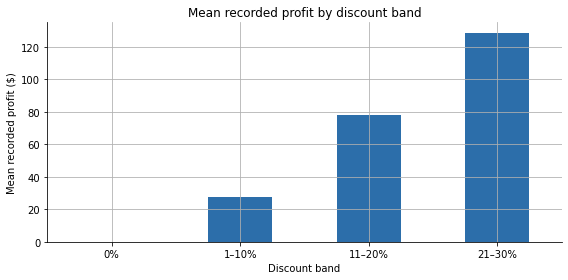

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
q2['avg_profit'].plot(kind='bar', color='#2c6eaa', rot=0, ax=ax)
ax.set_ylabel('Mean recorded profit ($)')
ax.set_xlabel('Discount band')
ax.set_title('Mean recorded profit by discount band')
plt.tight_layout()
plt.show()
plt.close()


**Interpretation.** `pd.cut` was used to create bins for the discounts. The mean recorded profit for each of the bins is plotted against the list price, which remains almost constant. Therefore, it is not the case that cheap items get bigger discounts. Rather, `Profit = Price × Discount%`. **Answer:** Recorded profit does not deteriorate at high discounts. The field cannot judge discount effectiveness from the data in the table. **Limitation:** Identity in the table, not a pricing experiment.

### Business Question 3 — How does recorded profitability vary across city markets, and is foot traffic associated with city-level recorded profitability?

**Business importance.** This is important for location decisions (i.e. decisions on expansion and staffing) in order to get a valid location key. Also it is important to check whether more foot traffic in a city leads to higher recorded profit. And: in this data set `StoreID` does not refer to a single store but 100 different stores each of which is found in all 10 different cities.

In [8]:
q3 = (df.groupby('StoreLocation')
        .agg(transactions=('Profit', 'size'), total_profit=('Profit', 'sum'),
             avg_profit=('Profit', 'mean'), median_profit=('Profit', 'median'),
             avg_traffic=('FootTraffic', 'mean'), median_traffic=('FootTraffic', 'median'))
        .sort_values('total_profit', ascending=False))
q3['profit_share_pct'] = 100 * q3['total_profit'] / q3['total_profit'].sum()
print(q3)
hi, lo = q3['avg_profit'].idxmax(), q3['avg_profit'].idxmin()
print('mean-profit spread vs overall mean %:',
      100 * (q3['avg_profit'].max() - q3['avg_profit'].min()) / q3['avg_profit'].mean())
print('highest vs lowest city:', hi, lo)
print('corr mean traffic vs mean recorded profit:', q3['avg_traffic'].corr(q3['avg_profit']))


               transactions  total_profit  avg_profit  median_profit  \
StoreLocation                                                          
Phoenix               20109    772,612.49       38.42           0.00   
Houston               20017    769,112.95       38.42           0.00   
San Diego             20074    761,954.99       37.96           0.00   
San Jose              20043    760,443.48       37.94           0.00   
Los Angeles           20100    757,148.14       37.67           0.00   
Dallas                19950    752,219.99       37.71           0.00   
Chicago               19977    750,098.08       37.55           0.00   
New York              19915    744,609.20       37.39           0.00   
Philadelphia          19853    739,966.76       37.27           0.00   
San Antonio           19962    736,496.36       36.89           0.00   

               avg_traffic  median_traffic  profit_share_pct  
StoreLocation                                                 
Phoenix  

**Interpretation.** The ranked city totals are flat (shares ~9.8–10.3%). The mean recorded profit varies by only a few percent between cities, while the medians are all $0. The traffic is not positively associated with the city mean recorded profit. **Answer:** The recorded profitability does not vary usefully between cities, and the foot traffic is not associated with the cities' recorded profit. **Limitation:** No valid store key.

### Business Question 4 — Purchasing activity and recorded profit over time

**Business importance.** Plans should separate demand shifts from calendar artefacts (month length, incomplete endpoints).


In [9]:
print(df['PurchaseDate'].min().date(), '→', df['PurchaseDate'].max().date())
monthly = df.groupby('YearMonth').agg(
    transactions=('Profit', 'size'),
    total_recorded_profit=('Profit', 'sum'),
    mean_recorded_profit=('Profit', 'mean'),
    mean_discount=('DiscountPercent', 'mean'))
print(monthly.head(2)); print(monthly.tail(2))
print(monthly[['mean_recorded_profit', 'mean_discount']].agg(['min', 'median', 'max']))
df.pivot_table(values='Profit', index=df['PurchaseDate'].dt.year,
               columns=df['PurchaseDate'].dt.quarter, aggfunc='size')


2020-07-14 → 2023-07-14
           transactions  total_recorded_profit  mean_recorded_profit  \
YearMonth                                                              
2020-07            3301             122,281.63                 37.04   
2020-08            5801             226,312.04                 39.01   

           mean_discount  
YearMonth                 
2020-07             7.35  
2020-08             7.69  
           transactions  total_recorded_profit  mean_recorded_profit  \
YearMonth                                                              
2023-06            5364             208,106.22                 38.80   
2023-07            2524              91,462.00                 36.24   

           mean_discount  
YearMonth                 
2023-06             7.60  
2023-07             7.41  
        mean_recorded_profit  mean_discount
min                    35.91           7.22
median                 37.64           7.49
max                    39.07           7.71


PurchaseDate,1,2,3,4
PurchaseDate,,,,
2020,NaN,NaN,"14,589.00","16,775.00"
2021,"16,458.00","16,652.00","16,782.00","16,777.00"
2022,"16,624.00","16,458.00","16,730.00","16,917.00"
2023,"16,270.00","16,444.00","2,524.00",NaN


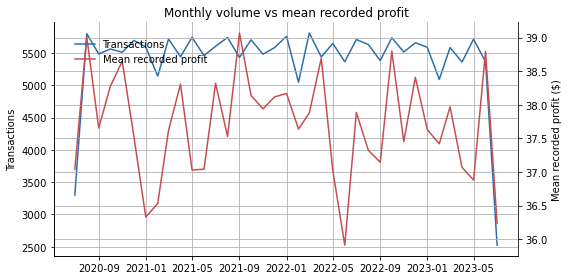

In [10]:
m = monthly.copy()
m.index = m.index.to_timestamp()
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(m.index, m['transactions'], color='#2c6eaa', label='Transactions')
ax1.set_ylabel('Transactions')
ax2 = ax1.twinx(); ax2.spines['right'].set_visible(True)
ax2.plot(m.index, m['mean_recorded_profit'], color='#c44e52', label='Mean recorded profit')
ax2.set_ylabel('Mean recorded profit ($)')
ax1.set_title('Monthly volume vs mean recorded profit')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88), frameon=False)
plt.tight_layout()
plt.show()
plt.close()


**Interpretation.** The span for this data is 14 Jul 2020–14 Jul 2023 covering 1,096 data points. July 2020 and July 2023 are partial, February is lower than average because there are fewer days in the month. The mean recorded profit and the mean discount are bounded within a narrow band, while the totals move in line with volume. **Answer:** From the above data the total recorded profit generally increases with transaction volume whilst the mean discount remains constant. Therefore apparent total-profit movement is generally a function of transaction numbers and not an indication of a change in recorded profit per transaction. **Limitation:** No holiday calendar has been included for this data.

### Business Question 5 - How does the annual income compare to the Spending Supplied Score and are there distinct Spending Supplied Score patterns for different Income groups?

**Business importance.** The CRM system often treats high income customers as high spend customers. This test is to explore whether there are any differences in the spending score for the various income groups and if so how they differ. `SpendingScore` is a supplied field, not calculated from the extracted data.

In [11]:
print('income min/max:', df['AnnualIncome'].min(), df['AnnualIncome'].max())
df['IncomeBand'] = pd.cut(
    df['AnnualIncome'],
    bins=[20000, 40000, 70000, 100000, 130000, 150001],
    labels=['20–40k', '40–70k', '70–100k', '100–130k', '130–150k'],
)
q5 = df.groupby('IncomeBand', observed=True).agg(
    n=('SpendingScore', 'size'), mean_score=('SpendingScore', 'mean'),
    median_score=('SpendingScore', 'median'), median_price=('ProductPrice', 'median'))
print(q5)
print('median score 130–150k vs 20–40k %:',
      100 * (q5.loc['130–150k', 'median_score'] / q5.loc['20–40k', 'median_score'] - 1))
print(df.groupby(pd.qcut(df['SpendingScore'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4']),
                 observed=True)['AnnualIncome'].agg(['median', 'mean']))


income min/max: 20001 150000
                n  mean_score  median_score  median_price
IncomeBand                                               
20–40k      30712       50.42         51.00        503.22
40–70k      46162       50.62         51.00        503.26
70–100k     46117       50.36         50.00        506.49
100–130k    46150       50.29         50.00        503.28
130–150k    30859       50.39         50.00        507.53
median score 130–150k vs 20–40k %: -1.9607843137254943
                 median      mean
SpendingScore                    
Q1            85,497.00 85,231.95
Q2            85,255.00 85,111.95
Q3            84,959.00 84,845.78
Q4            85,037.50 85,043.44


                 median      mean
SpendingScore                    
Q1            85,497.00 85,231.95
Q2            85,255.00 85,111.95
Q3            84,959.00 84,845.78
Q4            85,037.50 85,043.44


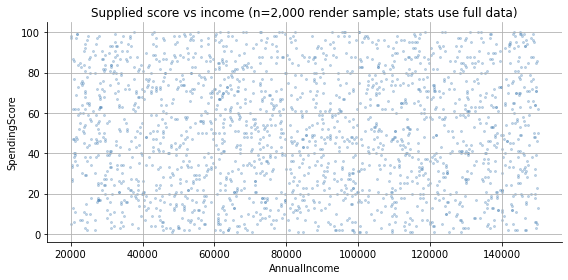

In [12]:
s = df.sample(2000, random_state=42)
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(s['AnnualIncome'], s['SpendingScore'], s=4, alpha=0.25, color='#2c6eaa', rasterized=True)
ax.set_xlabel('AnnualIncome'); ax.set_ylabel('SpendingScore')
ax.set_title('Supplied score vs income (n=2,000 render sample; stats use full data)')
plt.tight_layout()
plt.show()
plt.close()


**Interpretation.** Income is banded into $20,001–$150,000 wide groups. The mean/median supplied score for each of the banded groups is approximately 50. Within each banded group the score quartiles all have approximately the same median income. **Answer:** There is no difference in the spending-score patterns between income groups. **Limitation:** The `SpendingScore` is supplied not built from a purchase history.

### Business Question 6 - City-market marketing spend and recorded profit

Business importance. City marketing spend not resulting in same city profits means that the activity is being treated as a proven sales driver and large sum of money is being wasted.

In [13]:
city_m = (df.groupby('StoreLocation')
            .agg(mean_mkt=('MarketingExpenditure', 'mean'),
                 median_mkt=('MarketingExpenditure', 'median'),
                 mean_profit=('Profit', 'mean'),
                 total_profit=('Profit', 'sum'))
            .sort_values('mean_mkt', ascending=False))
print(city_m)
print('city mean-mkt range $:', city_m['mean_mkt'].min(), city_m['mean_mkt'].max(),
      '| spread vs mean %:', 100 * (city_m['mean_mkt'].max() - city_m['mean_mkt'].min()) / city_m['mean_mkt'].mean())
print(df.groupby(pd.qcut(df['MarketingExpenditure'], 4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high']),
                 observed=True)['Profit'].agg(['count', 'mean', 'median']))


               mean_mkt  median_mkt  mean_profit  total_profit
StoreLocation                                                 
San Diego      5,081.43    5,131.41        37.96    761,954.99
Dallas         5,076.24    5,092.85        37.71    752,219.99
Houston        5,044.49    5,042.74        38.42    769,112.95
New York       5,036.73    5,027.89        37.39    744,609.20
Los Angeles    5,034.09    5,027.18        37.67    757,148.14
Phoenix        5,033.86    5,023.40        38.42    772,612.49
San Antonio    5,023.18    4,994.74        36.89    736,496.36
Chicago        5,021.38    5,010.11        37.55    750,098.08
San Jose       5,018.61    4,984.61        37.94    760,443.48
Philadelphia   5,015.87    4,995.24        37.27    739,966.76
city mean-mkt range $: 5015.873486626706 5081.428039752914 | spread vs mean %: 1.3010499950964682
                      count  mean  median
MarketingExpenditure                     
Q1 low                50000 37.96    0.00
Q2                  

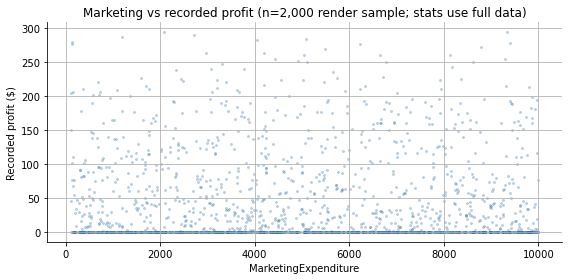

In [14]:
s = df.sample(2000, random_state=42)
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(s['MarketingExpenditure'], s['Profit'], s=4, alpha=0.25, color='#2c6eaa', rasterized=True)
ax.set_xlabel('MarketingExpenditure'); ax.set_ylabel('Recorded profit ($)')
ax.set_title('Marketing vs recorded profit (n=2,000 render sample; stats use full data)')
plt.tight_layout()
plt.show()
plt.close()


This can be interpreted as a City (i.e. StoreID not being a store but rather a data quality issue). City mean marketing spend is virtually constant (approx. 1% spread). For the marketing spend by quartile, the corresponding mean/median recorded profit is virtually the same for all ($0 median for all). In conclusion, there is no effective variation of marketing spend between city markets and corresponding recorded profit. A limit of this data is that marketing spend is recorded on a row by row basis with no mention of campaign dates, hence it is not possible to conduct an ROI analysis.

### Business Question 7 — Competitive pricing and recorded profit

**Business importance of Question 7:** The price-match rules should specify a range of values and check if being cheaper or more expensive than the competitors corresponds with being more or less profitable.


In [18]:
print(df['PriceGapPct'].quantile([0.25, 0.75]))
print('list vs competitor corr:', df['ProductPrice'].corr(df['CompetitorPrice']))
# Empirical IQR is about −10.0 to +10.0; ±10% is that IQR rounded to 1pp for readable bands
df['PricePosition'] = pd.cut(df['PriceGapPct'], bins=[-np.inf, -10, 10, np.inf],
                             labels=['Below competitor', 'Approximately aligned', 'Above competitor'])
df.groupby('PricePosition', observed=True).agg(
    n=('Profit', 'size'), avg_price=('ProductPrice', 'mean'),
    avg_gap_pct=('PriceGapPct', 'mean'), mean_profit=('Profit', 'mean'),
    median_profit=('Profit', 'median'))


0.25   -10.02
0.75     9.97
Name: PriceGapPct, dtype: float64
list vs competitor corr: 0.9738805258301909


,n,avg_price,avg_gap_pct,mean_profit,median_profit
PricePosition,,,,,
Below competitor,50128,503.84,-14.98,37.90,0.00
Approximately aligned,100021,505.32,0.00,37.67,0.00
Above competitor,49851,503.87,14.95,37.65,0.00


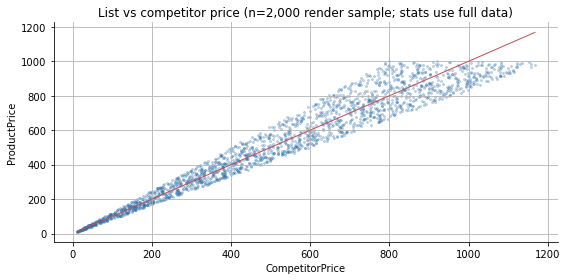

In [19]:
s = df.sample(2000, random_state=42)
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(s['CompetitorPrice'], s['ProductPrice'], s=4, alpha=0.25, color='#2c6eaa', rasterized=True)
lo, hi = min(s['CompetitorPrice'].min(), s['ProductPrice'].min()), max(s['CompetitorPrice'].max(), s['ProductPrice'].max())
ax.plot([lo, hi], [lo, hi], color='#c44e52', linewidth=1)
ax.set_xlabel('CompetitorPrice'); ax.set_ylabel('ProductPrice')
ax.set_title('List vs competitor price (n=2,000 render sample; stats use full data)')
plt.tight_layout()
plt.show()
plt.close()


Interpretation: The 25th/75th percentiles for the IQR of PriceGapPct are approximately -10% and +10%. The mean recorded profit for each of the three PricePosition categories (e.g. low) is approximately 38, while the medians are 0. The results indicate that prices track their competitors; the relative position of a price (e.g. low) does not seem to affect recorded profit. (Limitation: No data for individual SKUs.)

### Business Question 8 — Inventory, foot traffic and recorded profit

**Business importance.** This applies also when there is no recorded profit while floors are full of stock and there is a lot of foot traffic.


In [17]:
df['InvQ'] = pd.qcut(df['InventoryLevel'], 4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
df['TrafficQ'] = pd.qcut(df['FootTraffic'], 4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
inv = df.groupby('InvQ', observed=True)['Profit'].agg(['count', 'mean', 'median'])
tr = df.groupby('TrafficQ', observed=True)['Profit'].agg(['count', 'mean', 'median'])
print(inv); print(tr)
print('inv Q4 vs Q1 mean-profit %:', 100 * (inv.loc['Q4 high', 'mean'] / inv.loc['Q1 low', 'mean'] - 1))
print('traffic Q4 vs Q1 mean-profit %:', 100 * (tr.loc['Q4 high', 'mean'] / tr.loc['Q1 low', 'mean'] - 1))
print(df.pivot_table('Profit', index='InvQ', columns='TrafficQ', aggfunc='median', observed=True))
print('sales at inventory 0:', int((df['InventoryLevel'] == 0).sum()))


         count  mean  median
InvQ                        
Q1 low   51498 38.01    0.00
Q2       49685 37.45    0.00
Q3       49659 37.58    0.00
Q4 high  49158 37.83    0.00
          count  mean  median
TrafficQ                     
Q1 low    50179 37.89    0.00
Q2        49919 37.76    0.00
Q3        49964 37.36    0.00
Q4 high   49938 37.89    0.00
inv Q4 vs Q1 mean-profit %: -0.4707569359141961
traffic Q4 vs Q1 mean-profit %: 0.003099961193497869
TrafficQ  Q1 low   Q2   Q3  Q4 high
InvQ                               
Q1 low      0.00 0.00 0.00     0.00
Q2          0.00 0.00 0.00     0.00
Q3          0.00 0.00 0.00     0.00
Q4 high     0.00 0.00 0.00     0.00
sales at inventory 0: 1986


**Interpretation.** The graph of quartiles, the difference between Q4 and Q1 percentages and the median pivot are all near-flat. In other words, they all have means around $37–$38, with medians around $0. For this data, 1,986 sales occurred at an inventory level of 0 (i.e. not held on the shelves), which would not reflect the true on-hand stock. **Answer:** Neither inventory nor traffic (while potentially very useful operationally) provides useful discrimination of recorded profit in this data. This does not mean that the two fields are in any way irrelevant, simply that the fields provided do not have enough valid store-level data to establish their relevance for a discrimination of recorded profit.

## 7. Final discussion and conclusion

**Strengths.** Complete keys for questions that return data (even if only mechanical). All data reproduced from file `retail_data.csv`.

**Some major limitations:**
* One row per customer, hence all decision making is done on aggregated customer level.
* The “StoreID” is not a physical store, hence all cross-store decision making needs to be transformed into a cross-customer decision environment.
* As mentioned before, there is no campaign calendar and hence causal analysis is extremely limited.

**Overarching findings.**
1. **Profit field limitation.** The profit field (gain) is equal to list price * discount %. Thus the profit rankings equal the discount rankings.
2. **Weak commercial differentiation.** Categories and cities are almost equal on recorded margin, price and volume.
3. **Weak operational associations.** There is no evidence that marketing, store traffic, retail inventory, customer income or competitive position affects recorded profit.
4. **Structure constrains decisions.** All attempts to employ CRM, store and campaign-related analysis are hampered by the lack of a repeat customer ID, a valid store ID and a campaign grain, so the reader will find that none of these types of analysis are possible with this data.

**Business recommendations**
1. Do not allocate additional space in a city on the basis of such minor differences between categories (findings 2 & 4).
2. Do not target high-income customers as high spenders based on the score you were provided for section 3 of the assignment (finding 3).
3. Do not mislead others into believing that marketing, traffic or stock can increase recorded profit (finding 3).
4. The ±10% comparison with competitors in Section 3 is presented as an IQR band. It should not be interpreted as a rule for recorded profit.
5. Year-on-year is restricted to complete months (e.g. Jul-20 vs. Jul-23).

**Data-quality recommendations**
1. This figure should be replaced by the price less the independently measured cost of goods sold for the period, before any attempt has been made to apply mark downs to the recorded profit for the period, to assess the performance of the retail assortment (finding 1).
2. Link each store key to one location before you try to attribute locally (finding 4).
3. Investigate zero-inventory sales and inconsistent discount flags (finding 4).
4. Campaign data (as required for ROI analysis of individual marketing campaigns) and store on-hand inventory/traffic data at a grain level to support appropriate attribution for sales (Findings 3 & 4).

## 8. References

dfasure (n.d.) *Retail-Business-Data-Analysis*. GitHub. Available at: https://github.com/dfasure/Retail-Business-Data-Analysis (Accessed: 17 September 2026). Column-name cross-check only.

Khan, A.R. (n.d.) *Retail Data*. Kaggle. Available at: https://www.kaggle.com/datasets/abdurraziq01/retail-data (Accessed: 17 September 2026).

The pandas development team (n.d.) *pandas documentation*. Available at: https://pandas.pydata.org/docs/ (Accessed: 17 September 2026).
